# E5 — Plant-Health Real-Image Acquisition-Nuisance Phase Diagram

**Paper question:** On real potato-leaf disease images, can a plausible acquisition nuisance remain initially weaker than disease morphology, yet become the preferred clustering structure under misaligned consistency regularization?

> **Research-integrity note.** E4–E4d are preserved negative MNIST investigations. E5 moves to a welfare-facing domain rather than tuning MNIST further. The dataset, splits, nuisance-strength grid, augmentation probabilities, lambda grid, representation, and success criteria below are fixed before this run. Do not alter them after inspecting results.

## Human-welfare motivation

Plant disease recognition matters because unreliable clustering around camera/illumination conditions rather than disease morphology could undermine downstream crop monitoring and decision support. E5 therefore uses real potato disease images while keeping acquisition nuisance assignment controlled and independent of disease class.

## Semantic and nuisance factors

- **Semantic:** Potato Early Blight vs Potato Late Blight.
- **Controlled nuisance:** warm/cool white-balance style, assigned 50/50 within each disease class.
- **Misaligned augmentation:** lesion/detail evidence is blurred more often than the white-balance nuisance is reversed.
- **Aligned control:** nuisance reversal is more frequent than semantic-detail blur.

The nuisance is synthetic and controlled; the disease images are real. This experiment does **not** claim field deployment performance.

## 0. Kaggle setup

1. Add Kaggle dataset **PlantVillage Dataset** by `abdallahalidev` to the notebook inputs.
2. Enable **Internet** because torchvision may download ImageNet-pretrained ResNet-18 weights.
3. Enable a **GPU** (T4/P100 is recommended).
4. Start from a clean session and run all cells.

Suggested Kaggle title:

**Trustworthy Clustering E5 - Plant Disease Acquisition Nuisance**

In [1]:
from pathlib import Path
import glob, json, sys, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
from torchvision.transforms import functional as TF
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.linear_model import LogisticRegression

DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT=Path('/kaggle/working/E5_plant_health_phase_diagram')
OUT.mkdir(parents=True,exist_ok=True)

CONFIG={
    'experiment_id':'E5',
    'semantic_classes':['Potato___Early_blight','Potato___Late_blight'],
    'train_per_class':500,
    'test_per_class':200,
    'split_seed':2026,
    'seeds':[11,22,33,44,55],
    'feature_model':'ImageNet-pretrained ResNet18 frozen penultimate features',
    'pca_dim':32,
    'nuisance_mu_grid':[0.00,0.05,0.10,0.15,0.20,0.25,0.30],
    'nuisance_sigma':0.03,
    'nuisance_clip':0.35,
    'misaligned_alpha':0.25,
    'misaligned_q':0.05,
    'aligned_alpha':0.05,
    'aligned_q':0.25,
    'augmentation_views':2,
    'blur_kernel':11,
    'blur_sigma':3.0,
    'lambda_grid':[0,1,2,4,8,12,16,24,32],
    'kmeans_n_init':50,
    'projection_steps':250,
    'projection_lr':0.02,
    'consistency_temperature':0.35,
    'semantic_baseline_margin':0.10,
    'majority_fraction':0.60,
    'batch_size':128,
}
(OUT/'config.json').write_text(json.dumps(CONFIG,indent=2))

print('Python:',sys.version)
print('Torch:',torch.__version__)
print('Device:',DEVICE)
print(json.dumps(CONFIG,indent=2))
if DEVICE.type!='cuda':
    print('WARNING: E5 is designed to run much faster with a Kaggle GPU.')

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.10.0+cu128
Device: cuda
{
  "experiment_id": "E5",
  "semantic_classes": [
    "Potato___Early_blight",
    "Potato___Late_blight"
  ],
  "train_per_class": 500,
  "test_per_class": 200,
  "split_seed": 2026,
  "seeds": [
    11,
    22,
    33,
    44,
    55
  ],
  "feature_model": "ImageNet-pretrained ResNet18 frozen penultimate features",
  "pca_dim": 32,
  "nuisance_mu_grid": [
    0.0,
    0.05,
    0.1,
    0.15,
    0.2,
    0.25,
    0.3
  ],
  "nuisance_sigma": 0.03,
  "nuisance_clip": 0.35,
  "misaligned_alpha": 0.25,
  "misaligned_q": 0.05,
  "aligned_alpha": 0.05,
  "aligned_q": 0.25,
  "augmentation_views": 2,
  "blur_kernel": 11,
  "blur_sigma": 3.0,
  "lambda_grid": [
    0,
    1,
    2,
    4,
    8,
    12,
    16,
    24,
    32
  ],
  "kmeans_n_init": 50,
  "projection_steps": 250,
  "projection_lr": 0.02,
  "consistency_temperature": 0.35,
  "semantic_baseline_margin": 0.1,
  "majority_fraction": 

## 1. Locate the real PlantVillage potato classes and create a fixed split

In [2]:
def locate_class_dir(class_name):
    patterns=[
        f'/kaggle/input/**/color/{class_name}',
        f'/kaggle/input/**/{class_name}',
    ]
    hits=[]
    for pat in patterns:
        hits.extend(glob.glob(pat,recursive=True))
    hits=sorted(set([h for h in hits if Path(h).is_dir()]))
    # Prefer the canonical color folder if present.
    color_hits=[h for h in hits if '/color/' in h]
    if color_hits: return Path(color_hits[0])
    if hits: return Path(hits[0])
    raise FileNotFoundError(
        f'Could not find {class_name}. Add Kaggle dataset abdallahalidev/plantvillage-dataset.'
    )

EARLY_DIR=locate_class_dir('Potato___Early_blight')
LATE_DIR=locate_class_dir('Potato___Late_blight')
print('Early:',EARLY_DIR)
print('Late :',LATE_DIR)

def image_files(folder):
    exts={'.jpg','.jpeg','.png','.JPG','.JPEG','.PNG'}
    return sorted([p for p in folder.iterdir() if p.suffix in exts])

early=image_files(EARLY_DIR)
late=image_files(LATE_DIR)
print('Available Early:',len(early),'Late:',len(late))

need=CONFIG['train_per_class']+CONFIG['test_per_class']
assert len(early)>=need and len(late)>=need, 'Not enough images for locked split.'

rng=np.random.default_rng(CONFIG['split_seed'])
def fixed_split(paths):
    ids=np.arange(len(paths)); rng.shuffle(ids)
    train=[paths[i] for i in ids[:CONFIG['train_per_class']]]
    test=[paths[i] for i in ids[CONFIG['train_per_class']:need]]
    return train,test

e_tr,e_te=fixed_split(early)
l_tr,l_te=fixed_split(late)

TRAIN_PATHS=e_tr+l_tr
TRAIN_Y=np.array([0]*len(e_tr)+[1]*len(l_tr),dtype=int)
TEST_PATHS=e_te+l_te
TEST_Y=np.array([0]*len(e_te)+[1]*len(l_te),dtype=int)

print('Train:',len(TRAIN_PATHS),'class counts:',np.bincount(TRAIN_Y))
print('Test :',len(TEST_PATHS),'class counts:',np.bincount(TEST_Y))

Early: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Potato___Early_blight
Late : /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Potato___Late_blight
Available Early: 1000 Late: 1000
Train: 1000 class counts: [500 500]
Test : 400 class counts: [200 200]


## 2. Controlled acquisition nuisance

Each image receives a nuisance group \(N\in\{-1,+1\}\), balanced exactly within each disease class.

For nuisance strength \(\mu_N\):

\[
g = \mu_N N + \sigma_N\epsilon,
\qquad \sigma_N=0.03.
\]

The observed nuisance is a red/blue white-balance shift:

- positive \(g\): warmer/redder acquisition;
- negative \(g\): cooler/bluer acquisition.

This mimics a camera/illumination condition while remaining independent of disease class by construction.

In [3]:
def balanced_nuisance(y,seed):
    rng=np.random.default_rng(seed)
    N=np.empty(len(y),dtype=np.int8)
    for cls in np.unique(y):
        ids=np.where(y==cls)[0].copy(); rng.shuffle(ids)
        half=len(ids)//2
        N[ids[:half]]=-1; N[ids[half:]]=1
    return N

def nuisance_evidence(N,mu_n,seed):
    rng=np.random.default_rng(seed)
    g=mu_n*N.astype(np.float32)+CONFIG['nuisance_sigma']*rng.normal(size=len(N)).astype(np.float32)
    return np.clip(g,-CONFIG['nuisance_clip'],CONFIG['nuisance_clip'])

def corr(a,b):
    return float(np.corrcoef(np.asarray(a,float),np.asarray(b,float))[0,1])

## 3. Frozen ImageNet-pretrained ResNet-18 representation

No disease or nuisance labels are used to train the representation. ResNet-18 remains frozen. We use its 512-dimensional penultimate features, then fit PCA on training features only and standardize the PCA coordinates using training statistics.

In [4]:
weights=ResNet18_Weights.DEFAULT
model=resnet18(weights=weights)
model.fc=nn.Identity()
model=model.to(DEVICE).eval()
for p in model.parameters(): p.requires_grad=False

MEAN=torch.tensor(weights.transforms().mean,dtype=torch.float32).view(3,1,1)
STD=torch.tensor(weights.transforms().std,dtype=torch.float32).view(3,1,1)

class PlantViewDataset(Dataset):
    def __init__(self,paths,g,sem_flags=None,nui_flags=None):
        self.paths=paths
        self.g=np.asarray(g,dtype=np.float32)
        self.sem_flags=np.zeros(len(paths),dtype=bool) if sem_flags is None else np.asarray(sem_flags,bool)
        self.nui_flags=np.zeros(len(paths),dtype=bool) if nui_flags is None else np.asarray(nui_flags,bool)
    def __len__(self): return len(self.paths)
    def __getitem__(self,i):
        x=read_image(str(self.paths[i])).float()/255.0
        if x.shape[0]==1: x=x.repeat(3,1,1)
        if x.shape[0]>3: x=x[:3]
        x=TF.resize(x,[224,224],antialias=True)

        g=float(self.g[i])
        if self.nui_flags[i]: g=-g
        # Warm/cool white-balance nuisance.
        x=x.clone()
        x[0]=torch.clamp(x[0]*(1.0+g),0,1)
        x[2]=torch.clamp(x[2]*(1.0-g),0,1)

        # Semantic-detail corruption: strong low-pass blur, preserving global color cast.
        if self.sem_flags[i]:
            x=TF.gaussian_blur(x,kernel_size=[CONFIG['blur_kernel'],CONFIG['blur_kernel']],
                               sigma=[CONFIG['blur_sigma'],CONFIG['blur_sigma']])
        x=(x-MEAN)/STD
        return x

@torch.no_grad()
def extract_features(paths,g,sem_flags=None,nui_flags=None):
    ds=PlantViewDataset(paths,g,sem_flags,nui_flags)
    dl=DataLoader(ds,batch_size=CONFIG['batch_size'],shuffle=False,
                  num_workers=2,pin_memory=(DEVICE.type=='cuda'))
    out=[]
    for xb in dl:
        xb=xb.to(DEVICE,non_blocking=True)
        out.append(model(xb).cpu().numpy())
    return np.concatenate(out,axis=0).astype(np.float32)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]


## 4. Baseline phase map over acquisition nuisance strength

For every \((\mu_N,\text{seed})\):

1. assign nuisance groups independently within each disease class;
2. render the acquisition nuisance;
3. extract frozen ResNet features;
4. fit PCA-32 + standardization on training features;
5. fit KMeans (`n_init=50`);
6. initialize a one-dimensional projection from the KMeans centroid difference.

Only a **semantic-dominant** baseline can later support a regularizer-induced reversal claim.

In [5]:
def best_perm_acc(pred,target):
    target_pm=np.where(np.asarray(target)==1,1,-1)
    pred_pm=np.where(np.asarray(pred)==1,1,-1)
    return float(max(np.mean(pred_pm==target_pm),np.mean(-pred_pm==target_pm)))

def eval_clusters(pred,semantic,nuisance):
    return {
        'semantic_accuracy':best_perm_acc(pred,semantic),
        'nuisance_accuracy':best_perm_acc(pred,nuisance),
        'semantic_ari':float(adjusted_rand_score(semantic,pred)),
        'nuisance_ari':float(adjusted_rand_score(nuisance,pred)),
    }

def build_condition(mu_n,seed):
    Ntr=balanced_nuisance(TRAIN_Y,10000+seed)
    Nte=balanced_nuisance(TEST_Y,20000+seed)
    gtr=nuisance_evidence(Ntr,mu_n,30000+seed)
    gte=nuisance_evidence(Nte,mu_n,40000+seed)

    ftr=extract_features(TRAIN_PATHS,gtr)
    fte=extract_features(TEST_PATHS,gte)

    pca=PCA(n_components=CONFIG['pca_dim'],svd_solver='randomized',random_state=50000+seed)
    zr_tr=pca.fit_transform(ftr)
    zr_te=pca.transform(fte)
    mean=zr_tr.mean(0); std=np.maximum(zr_tr.std(0),1e-8)
    ztr=((zr_tr-mean)/std).astype(np.float32)
    zte=((zr_te-mean)/std).astype(np.float32)

    km=KMeans(n_clusters=2,n_init=CONFIG['kmeans_n_init'],random_state=60000+seed)
    km.fit(ztr)
    pred=km.predict(zte)
    ev=eval_clusters(pred,TEST_Y,Nte)

    w0=km.cluster_centers_[1]-km.cluster_centers_[0]
    w0=(w0/(np.linalg.norm(w0)+1e-12)).astype(np.float32)

    # Diagnostic nuisance probe only; never used for optimization.
    probe=LogisticRegression(max_iter=2000,random_state=seed).fit(ztr,Ntr)
    nuisance_probe=probe.score(zte,Nte)

    return dict(mu_n=mu_n,seed=seed,Ntr=Ntr,Nte=Nte,gtr=gtr,gte=gte,
                pca=pca,mean=mean,std=std,ztr=ztr,zte=zte,w0=w0,
                nuisance_probe_accuracy=nuisance_probe,**{f'kmeans_{k}':v for k,v in ev.items()})

condition_data={}; baseline_rows=[]
for mu_n in CONFIG['nuisance_mu_grid']:
    condition_data[mu_n]={}
    for seed in CONFIG['seeds']:
        print(f'Baseline features mu={mu_n:.2f}, seed={seed}')
        d=build_condition(mu_n,seed)
        condition_data[mu_n][seed]=d
        baseline_rows.append({
            'mu_n':mu_n,'seed':seed,
            'semantic_nuisance_corr_train':corr(TRAIN_Y,d['Ntr']),
            'semantic_nuisance_corr_test':corr(TEST_Y,d['Nte']),
            'nuisance_probe_accuracy':d['nuisance_probe_accuracy'],
            'kmeans_semantic_ari':d['kmeans_semantic_ari'],
            'kmeans_nuisance_ari':d['kmeans_nuisance_ari'],
        })

baseline=pd.DataFrame(baseline_rows)
baseline.to_csv(OUT/'E5_baseline_runs.csv',index=False)
baseline_summary=baseline.groupby('mu_n').agg(
    median_nuisance_probe_accuracy=('nuisance_probe_accuracy','median'),
    median_kmeans_semantic_ari=('kmeans_semantic_ari','median'),
    median_kmeans_nuisance_ari=('kmeans_nuisance_ari','median'),
).reset_index()
baseline_summary.to_csv(OUT/'E5_baseline_summary.csv',index=False)
display(baseline_summary)

Baseline features mu=0.00, seed=11
Baseline features mu=0.00, seed=22
Baseline features mu=0.00, seed=33
Baseline features mu=0.00, seed=44
Baseline features mu=0.00, seed=55
Baseline features mu=0.05, seed=11
Baseline features mu=0.05, seed=22
Baseline features mu=0.05, seed=33
Baseline features mu=0.05, seed=44
Baseline features mu=0.05, seed=55
Baseline features mu=0.10, seed=11
Baseline features mu=0.10, seed=22
Baseline features mu=0.10, seed=33
Baseline features mu=0.10, seed=44
Baseline features mu=0.10, seed=55
Baseline features mu=0.15, seed=11
Baseline features mu=0.15, seed=22
Baseline features mu=0.15, seed=33
Baseline features mu=0.15, seed=44
Baseline features mu=0.15, seed=55
Baseline features mu=0.20, seed=11
Baseline features mu=0.20, seed=22
Baseline features mu=0.20, seed=33
Baseline features mu=0.20, seed=44
Baseline features mu=0.20, seed=55
Baseline features mu=0.25, seed=11
Baseline features mu=0.25, seed=22
Baseline features mu=0.25, seed=33
Baseline features mu

,mu_n,median_nuisance_probe_accuracy,median_kmeans_semantic_ari,median_kmeans_nuisance_ari
0,0.00,0.5025,0.921403,-0.002412
1,0.05,0.7925,0.502932,-0.002248
2,0.10,0.9500,0.427684,-0.001722
3,0.15,0.9925,0.883308,-0.001610
4,0.20,0.9975,0.713310,-0.001274
5,0.25,1.0000,-0.002513,1.000000
6,0.30,1.0000,-0.002513,1.000000


## 5. KMeans-anchored projection and baseline regimes

We use the same architecture that will receive consistency regularization. Baseline regime is defined using held-out ARI gap:

- **semantic-dominant:** \(ARI_S-ARI_N\ge0.10\);
- **nuisance-dominant:** \(ARI_N-ARI_S\ge0.10\);
- otherwise **near-boundary**.

In [6]:
class ProjectionHead(nn.Module):
    def __init__(self,w0):
        super().__init__(); self.w=nn.Parameter(torch.tensor(w0,dtype=torch.float32,device=DEVICE))
    def wn(self): return self.w/(self.w.norm()+1e-8)
    def forward(self,z): return z@self.wn()

def Dloss(y): return (y*y).mean()-y.abs().mean()**2

def Closs(y,ya):
    t=CONFIG['consistency_temperature']
    return ((torch.tanh(y[None,:]/t)-torch.tanh(ya/t))**2).mean()/4

def fit_projection(ztr,w0,lam,za=None):
    z=torch.tensor(ztr,dtype=torch.float32,device=DEVICE)
    za_t=None if za is None else torch.tensor(za,dtype=torch.float32,device=DEVICE)
    h=ProjectionHead(w0).to(DEVICE)
    opt=torch.optim.Adam(h.parameters(),lr=CONFIG['projection_lr'])
    if za_t is not None: K,n,d=za_t.shape
    for _ in range(CONFIG['projection_steps']):
        y=h(z); loss=Dloss(y)
        if lam>0:
            ya=(za_t.reshape(K*n,d)@h.wn()).reshape(K,n)
            loss=loss+lam*Closs(y,ya)
        opt.zero_grad(); loss.backward(); opt.step()
    return h

def pred_head(h,z):
    with torch.no_grad():
        zz=torch.tensor(z,dtype=torch.float32,device=DEVICE)
        return (h(zz)>=0).long().cpu().numpy()

def heldout_agreement(h,zte,za_te):
    with torch.no_grad():
        z=torch.tensor(zte,dtype=torch.float32,device=DEVICE)
        za=torch.tensor(za_te,dtype=torch.float32,device=DEVICE)
        y=h(z); K,n,d=za.shape
        ya=(za.reshape(K*n,d)@h.wn()).reshape(K,n)
        return float(((ya>=0)==(y[None,:]>=0)).float().mean().item())

p0=[]
for mu_n in CONFIG['nuisance_mu_grid']:
    for seed in CONFIG['seeds']:
        d=condition_data[mu_n][seed]
        h=fit_projection(d['ztr'],d['w0'],0,None)
        ev=eval_clusters(pred_head(h,d['zte']),TEST_Y,d['Nte'])
        p0.append({'mu_n':mu_n,'seed':seed,**ev})
p0=pd.DataFrame(p0)
p0.to_csv(OUT/'E5_projection_lambda0_runs.csv',index=False)

p0s=p0.groupby('mu_n').agg(
    median_semantic_ari=('semantic_ari','median'),
    median_nuisance_ari=('nuisance_ari','median'),
).reset_index()

def regime(row):
    gap=row['median_nuisance_ari']-row['median_semantic_ari']
    m=CONFIG['semantic_baseline_margin']
    if gap<=-m: return 'semantic-dominant'
    if gap>=m: return 'nuisance-dominant'
    return 'near-boundary'

p0s['baseline_regime']=p0s.apply(regime,axis=1)
p0s.to_csv(OUT/'E5_projection_baseline_regimes.csv',index=False)
display(p0s)

# Minimum requirement: clean/no-nuisance condition must not already be nuisance-dominant.
clean=p0s[np.isclose(p0s.mu_n,0.0)].iloc[0]
CLEAN_BASELINE_OK=bool(clean.baseline_regime=='semantic-dominant')
print('CLEAN_BASELINE_OK:',CLEAN_BASELINE_OK)
if not CLEAN_BASELINE_OK:
    raise RuntimeError('STOP: mu_N=0 baseline is not semantic-dominant. Preserve E5 as negative; do not tune this version.')

,mu_n,median_semantic_ari,median_nuisance_ari,baseline_regime
0,0.00,0.940752,-0.002412,semantic-dominant
1,0.05,0.931052,-0.002287,semantic-dominant
2,0.10,0.902255,-0.001886,semantic-dominant
3,0.15,0.883308,-0.001885,semantic-dominant
4,0.20,0.864561,-0.000905,semantic-dominant
5,0.25,-0.002513,1.000000,nuisance-dominant
6,0.30,-0.002513,1.000000,nuisance-dominant


CLEAN_BASELINE_OK: True


## 6. Generate sampled acquisition/semantic augmentations

For each base image:

- semantic corruption: Gaussian blur with probability \(\alpha\), degrading lesion texture/detail while largely preserving global white balance;
- nuisance corruption: flip the white-balance coefficient \(g\mapsto-g\) with probability \(q\).

Misaligned: \(\alpha=0.25>q=0.05\).

Aligned control: \(\alpha=0.05<q=0.25\).

In [7]:
def project_new_features(raw,pca,mean,std):
    zr=pca.transform(raw)
    return ((zr-mean)/std).astype(np.float32)

def aug_features(paths,g,d,alpha,q,seed):
    rng=np.random.default_rng(seed)
    views=[]
    for _ in range(CONFIG['augmentation_views']):
        sf=rng.random(len(paths))<alpha
        nf=rng.random(len(paths))<q
        raw=extract_features(paths,g,sem_flags=sf,nui_flags=nf)
        views.append(project_new_features(raw,d['pca'],d['mean'],d['std']))
    return np.stack(views)

aug={}
for mu_n in CONFIG['nuisance_mu_grid']:
    aug[mu_n]={}
    mu_code=int(round(mu_n*1000))
    for seed in CONFIG['seeds']:
        print(f'Augmented features mu={mu_n:.2f}, seed={seed}')
        d=condition_data[mu_n][seed]; aug[mu_n][seed]={}
        for cond,a,q,off in [
            ('misaligned',CONFIG['misaligned_alpha'],CONFIG['misaligned_q'],0),
            ('aligned',CONFIG['aligned_alpha'],CONFIG['aligned_q'],100000),
        ]:
            aug[mu_n][seed][cond]=(
                aug_features(TRAIN_PATHS,d['gtr'],d,a,q,70000+mu_code*10+seed+off),
                aug_features(TEST_PATHS,d['gte'],d,a,q,80000+mu_code*10+seed+off),
            )
print('All sampled augmented features prepared.')

Augmented features mu=0.00, seed=11
Augmented features mu=0.00, seed=22
Augmented features mu=0.00, seed=33
Augmented features mu=0.00, seed=44
Augmented features mu=0.00, seed=55
Augmented features mu=0.05, seed=11
Augmented features mu=0.05, seed=22
Augmented features mu=0.05, seed=33
Augmented features mu=0.05, seed=44
Augmented features mu=0.05, seed=55
Augmented features mu=0.10, seed=11
Augmented features mu=0.10, seed=22
Augmented features mu=0.10, seed=33
Augmented features mu=0.10, seed=44
Augmented features mu=0.10, seed=55
Augmented features mu=0.15, seed=11
Augmented features mu=0.15, seed=22
Augmented features mu=0.15, seed=33
Augmented features mu=0.15, seed=44
Augmented features mu=0.15, seed=55
Augmented features mu=0.20, seed=11
Augmented features mu=0.20, seed=22
Augmented features mu=0.20, seed=33
Augmented features mu=0.20, seed=44
Augmented features mu=0.20, seed=55
Augmented features mu=0.25, seed=11
Augmented features mu=0.25, seed=22
Augmented features mu=0.25, 

## 7. Full food-security real-image phase sweep

A **valid regularizer-induced reversal** requires:

1. baseline at that nuisance strength is semantic-dominant;
2. \(\lambda>0\);
3. median nuisance ARI exceeds median semantic ARI;
4. at least 60% of seeds are nuisance-dominated.

A nuisance-dominant baseline never counts as a consistency-induced reversal.

In [8]:
rows=[]
for mu_n in CONFIG['nuisance_mu_grid']:
    for seed in CONFIG['seeds']:
        d=condition_data[mu_n][seed]
        for cond in ['misaligned','aligned']:
            za_tr,za_te=aug[mu_n][seed][cond]
            for lam in CONFIG['lambda_grid']:
                h=fit_projection(d['ztr'],d['w0'],lam,None if lam==0 else za_tr)
                ev=eval_clusters(pred_head(h,d['zte']),TEST_Y,d['Nte'])
                agr=np.nan if lam==0 else heldout_agreement(h,d['zte'],za_te)
                rows.append({
                    'mu_n':mu_n,'condition':cond,'seed':seed,'lambda':lam,**ev,
                    'ari_gap_nuisance_minus_semantic':ev['nuisance_ari']-ev['semantic_ari'],
                    'nuisance_dominated':float(ev['nuisance_ari']>ev['semantic_ari']),
                    'augmentation_agreement':agr,
                })

runs=pd.DataFrame(rows)
runs.to_csv(OUT/'E5_seed_level_runs.csv',index=False)
summary=runs.groupby(['mu_n','condition','lambda']).agg(
    median_semantic_ari=('semantic_ari','median'),
    median_nuisance_ari=('nuisance_ari','median'),
    median_ari_gap=('ari_gap_nuisance_minus_semantic','median'),
    p_nuisance_dominated=('nuisance_dominated','mean'),
    median_augmentation_agreement=('augmentation_agreement','median'),
).reset_index()
summary=summary.merge(p0s[['mu_n','baseline_regime']],on='mu_n',how='left')
summary.to_csv(OUT/'E5_phase_summary.csv',index=False)
display(summary.head(30))

,mu_n,condition,lambda,median_semantic_ari,median_nuisance_ari,median_ari_gap,p_nuisance_dominated,median_augmentation_agreement,baseline_regime
0,0.00,aligned,0,0.940752,-0.002412,-0.942863,0.0,NaN,semantic-dominant
1,0.00,aligned,1,0.931052,-0.002487,-0.933540,0.0,0.99500,semantic-dominant
2,0.00,aligned,2,0.931052,-0.002412,-0.933339,0.0,0.99500,semantic-dominant
3,0.00,aligned,4,0.940752,-0.002487,-0.943164,0.0,0.99625,semantic-dominant
4,0.00,aligned,8,0.940752,-0.002412,-0.943164,0.0,0.99625,semantic-dominant
5,0.00,aligned,12,0.931052,-0.002487,-0.933539,0.0,0.99625,semantic-dominant
6,0.00,aligned,16,0.921403,-0.002412,-0.923815,0.0,0.99625,semantic-dominant
7,0.00,aligned,24,0.902255,-0.002411,-0.904666,0.0,0.99625,semantic-dominant
8,0.00,aligned,32,0.902255,-0.002411,-0.904666,0.0,0.99750,semantic-dominant
9,0.00,misaligned,0,0.940752,-0.002412,-0.942863,0.0,NaN,semantic-dominant


## 8. Identify valid reversal cells

In [9]:
mis=summary[summary.condition=='misaligned'].copy()
ali=summary[summary.condition=='aligned'].copy()

reversal=mis[
    (mis.baseline_regime=='semantic-dominant')
    & (mis['lambda']>0)
    & (mis.median_ari_gap>0)
    & (mis.p_nuisance_dominated>=CONFIG['majority_fraction'])
].copy()
aligned_bad=ali[
    (ali.baseline_regime=='semantic-dominant')
    & (ali['lambda']>0)
    & (ali.median_ari_gap>0)
    & (ali.p_nuisance_dominated>=CONFIG['majority_fraction'])
].copy()

print('VALID MISALIGNED REVERSAL CELLS:')
display(reversal)
print('UNEXPECTED ALIGNED REVERSAL CELLS:')
display(aligned_bad)

VALID MISALIGNED REVERSAL CELLS:


,mu_n,condition,lambda,median_semantic_ari,median_nuisance_ari,median_ari_gap,p_nuisance_dominated,median_augmentation_agreement,baseline_regime


UNEXPECTED ALIGNED REVERSAL CELLS:


,mu_n,condition,lambda,median_semantic_ari,median_nuisance_ari,median_ari_gap,p_nuisance_dominated,median_augmentation_agreement,baseline_regime


## 9. Paper-facing figures

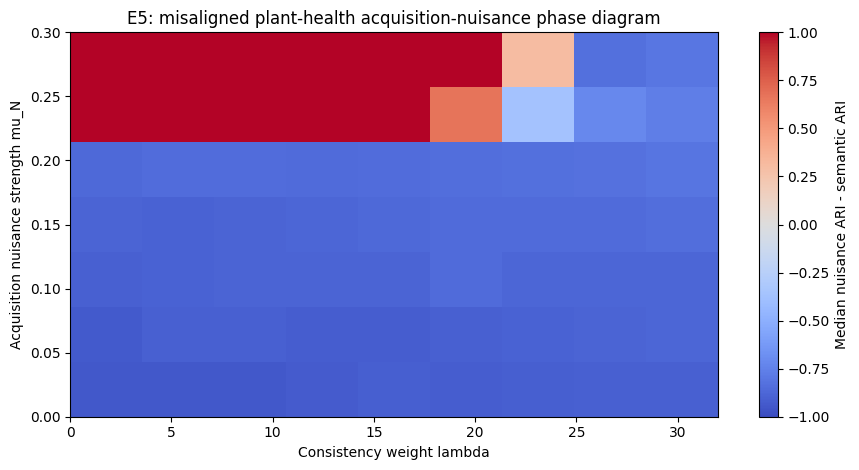

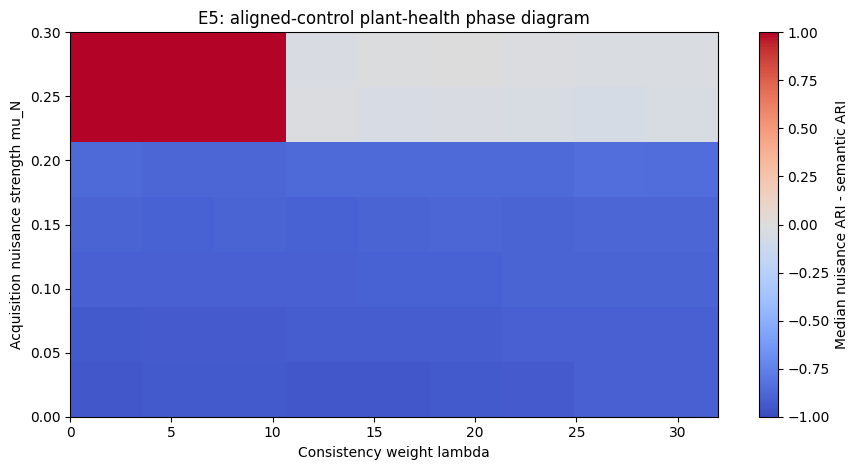

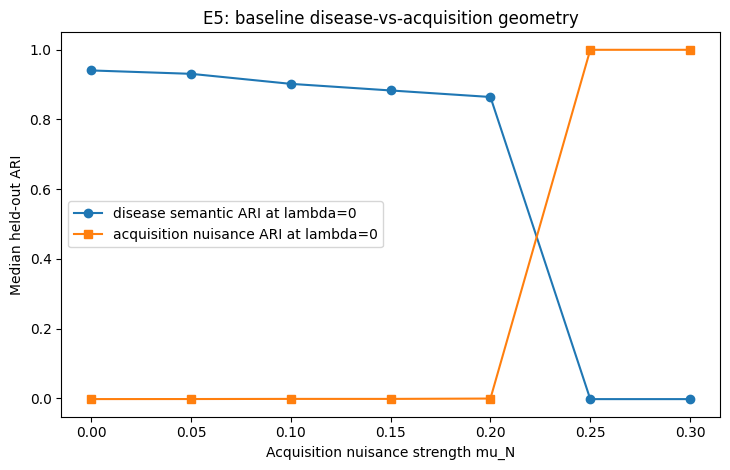

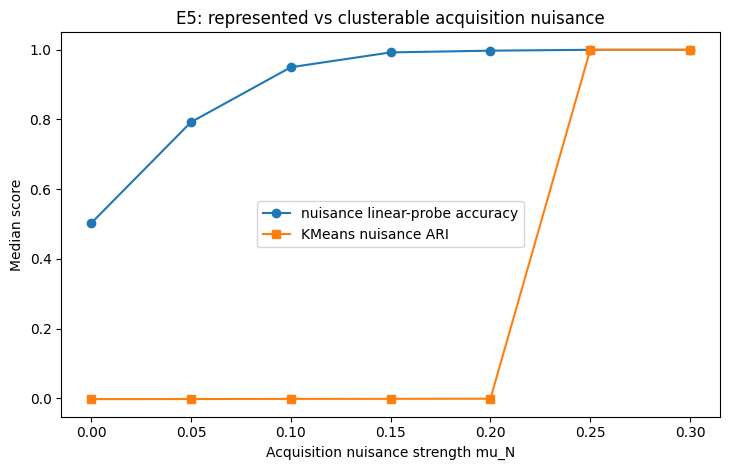

In [10]:
def phase_heatmap(df,title,filename):
    pivot=df.pivot(index='mu_n',columns='lambda',values='median_ari_gap')
    fig,ax=plt.subplots(figsize=(9,4.8))
    im=ax.imshow(pivot.values,aspect='auto',origin='lower',
                 extent=[pivot.columns.min(),pivot.columns.max(),pivot.index.min(),pivot.index.max()],
                 cmap='coolwarm',vmin=-1,vmax=1)
    ax.set_xlabel('Consistency weight lambda')
    ax.set_ylabel('Acquisition nuisance strength mu_N')
    ax.set_title(title)
    cb=plt.colorbar(im,ax=ax); cb.set_label('Median nuisance ARI - semantic ARI')
    plt.tight_layout(); plt.savefig(OUT/filename,dpi=200); plt.show()

phase_heatmap(mis,'E5: misaligned plant-health acquisition-nuisance phase diagram','E5_misaligned_phase_heatmap.png')
phase_heatmap(ali,'E5: aligned-control plant-health phase diagram','E5_aligned_phase_heatmap.png')

plt.figure(figsize=(7.4,4.8))
plt.plot(p0s.mu_n,p0s.median_semantic_ari,marker='o',label='disease semantic ARI at lambda=0')
plt.plot(p0s.mu_n,p0s.median_nuisance_ari,marker='s',label='acquisition nuisance ARI at lambda=0')
plt.xlabel('Acquisition nuisance strength mu_N'); plt.ylabel('Median held-out ARI')
plt.title('E5: baseline disease-vs-acquisition geometry')
plt.legend(); plt.tight_layout(); plt.savefig(OUT/'E5_baseline_geometry.png',dpi=200); plt.show()

plt.figure(figsize=(7.4,4.8))
plt.plot(baseline_summary.mu_n,baseline_summary.median_nuisance_probe_accuracy,marker='o',label='nuisance linear-probe accuracy')
plt.plot(baseline_summary.mu_n,baseline_summary.median_kmeans_nuisance_ari,marker='s',label='KMeans nuisance ARI')
plt.xlabel('Acquisition nuisance strength mu_N'); plt.ylabel('Median score')
plt.title('E5: represented vs clusterable acquisition nuisance')
plt.legend(); plt.tight_layout(); plt.savefig(OUT/'E5_represented_vs_clusterable_nuisance.png',dpi=200); plt.show()

## 10. Predeclared final checks

E5 is **paper-eligible as welfare-facing mechanism evidence** only if:

1. the no-nuisance baseline is semantic-dominant;
2. the nuisance-strength sweep creates a genuine clusterability gradient (multiple baseline regimes or at least +0.10 nuisance-ARI growth);
3. at least one valid misaligned reversal cell exists;
4. no majority reversal occurs under the aligned control inside a semantic-dominant baseline region;
5. all predeclared cells are present.

If criterion 3 fails, preserve E5 as a negative result. Do not tune this saved version.

In [11]:
regimes=set(p0s.baseline_regime.tolist())
nui_vals=baseline_summary.sort_values('mu_n').median_kmeans_nuisance_ari.values
gradient=float(nui_vals[-1]-nui_vals[0])
expected=len(CONFIG['nuisance_mu_grid'])*len(CONFIG['seeds'])*2*len(CONFIG['lambda_grid'])

checks={
    'clean_baseline_semantic_dominant':bool(CLEAN_BASELINE_OK),
    'nuisance_clusterability_gradient_present':bool(len(regimes)>=2 or gradient>=0.10),
    'valid_misaligned_reversal_exists':bool(len(reversal)>0),
    'aligned_control_has_no_majority_reversal':bool(len(aligned_bad)==0),
    'all_declared_cells_present':bool(len(runs)==expected),
}
print(checks)
(OUT/'sanity_checks.json').write_text(json.dumps(checks,indent=2))
PAPER_ELIGIBLE=all(checks.values())
print('\nE5 PAPER-ELIGIBLE:',PAPER_ELIGIBLE)
if PAPER_ELIGIBLE:
    print('E5 found a valid plant-health regularizer-induced acquisition-nuisance reversal region.')
else:
    print('E5 did not satisfy every predeclared criterion. Preserve the complete run; do not tune this saved version.')

{'clean_baseline_semantic_dominant': True, 'nuisance_clusterability_gradient_present': True, 'valid_misaligned_reversal_exists': False, 'aligned_control_has_no_majority_reversal': True, 'all_declared_cells_present': True}

E5 PAPER-ELIGIBLE: False
E5 did not satisfy every predeclared criterion. Preserve the complete run; do not tune this saved version.


## 11. Save run manifest

In [12]:
manifest={
    'experiment':'E5_plant_health_phase_diagram',
    'dataset':'PlantVillage potato Early Blight vs Late Blight',
    'purpose':'welfare-facing real-image acquisition-nuisance validation',
    'representation':CONFIG['feature_model'],
    'semantic_labels_used_for_representation_training':False,
    'semantic_labels_used_for_clustering_training':False,
    'nuisance_labels_used_for_clustering_training':False,
    'nuisance_assignment':'balanced exactly within disease class',
    'device':str(DEVICE),
    'python':sys.version,
    'torch':torch.__version__,
    'numpy':np.__version__,
    'pandas':pd.__version__,
}
(OUT/'run_manifest.json').write_text(json.dumps(manifest,indent=2))
print(json.dumps(manifest,indent=2))
print('\nE5 complete. Save this exact Kaggle version and download the entire output folder.')

{
  "experiment": "E5_plant_health_phase_diagram",
  "dataset": "PlantVillage potato Early Blight vs Late Blight",
  "purpose": "welfare-facing real-image acquisition-nuisance validation",
  "representation": "ImageNet-pretrained ResNet18 frozen penultimate features",
  "semantic_labels_used_for_representation_training": false,
  "semantic_labels_used_for_clustering_training": false,
  "nuisance_labels_used_for_clustering_training": false,
  "nuisance_assignment": "balanced exactly within disease class",
  "device": "cuda",
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "torch": "2.10.0+cu128",
  "numpy": "2.0.2",
  "pandas": "2.3.3"
}

E5 complete. Save this exact Kaggle version and download the entire output folder.
